# FX Pairs: Backtest and Signal Evaluation

**Chapter 16 - Strategy Simulation**

This notebook tests whether validation-set prediction ranks survive realistic FX execution.
The frozen registry contains 20-pair, equal-weight long-short baselines for the 1-, 5-, and
21-day labels. The analysis collapses byte-identical legacy hash duplicates before ranking or
adjusting for selection.

1. **Plumbing test** - isolate the engine from transaction-cost drag with random gross signals
2. **Parametric sweep** - reproduce existing results by default; write only when explicitly enabled
3. **Signal evaluation** - compare semantic variants and recompute selection adjustment in memory

**Book Reference:** Chapter 16, Sections 16.4-16.8

**Prerequisites:** Completed model training (Ch11-15) for this case study.

In [1]:
"""Ch16 Backtest and Signal Evaluation for the FX pairs case study."""

import sqlite3
import time
from collections import defaultdict
from dataclasses import replace
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import utils.style
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import get_entry_schemes_for, get_top_n_predictions
from case_studies.utils.uncertainty import (
    compute_cohort_metrics,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

In [2]:
CASE_STUDY_ID = "fx_pairs"
LABEL = ""
SPLIT = "validation"
TOP_K = 20
MAX_SYMBOLS = 0
SEED = 42
RUN_SWEEP = False
FORCE_REBACKTEST = False
TOP_N_PREDICTIONS = None

In [3]:
set_global_seeds(SEED)

## 1. A gross plumbing test isolates engine behavior

A random signal should have a Sharpe ratio near zero before costs. The production strategy pays
5 bps commission plus 2 bps slippage per traded leg. Applying those costs to a high-turnover
random strategy measures expected cost drag, not spurious engine alpha. The plumbing test
therefore sets both costs to zero while preserving the production calendar, execution timing,
and long-short mechanics.

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_PATH = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")
if not LABEL:
    LABEL = bt_config.primary_label

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Execution:     {bt_config.execution_delay}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

=== Protocol Term Sheet ===
  Case study:    fx_pairs
  Label:         fwd_ret_1d
  Calendar:      FX
  Cadence:       daily_ny_close
  Execution:     next_bar_open
  Commission:    5.0 bps
  Slippage:      2.0 bps
  Total cost:    7.0 bps/leg
  Long/short:    True



In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
validation_end = prices["timestamp"].max()
holdout_start = datetime.fromisoformat(bt_config.holdout_start).date()
if isinstance(validation_end, datetime):
    validation_end = validation_end.date()
assert validation_end < holdout_start
print(f"Prices: {len(prices):,} rows, {n_assets} assets")
print(f"Validation ends {validation_end}; sealed holdout starts {holdout_start}")

Prices: 41,280 rows, 20 assets
Validation ends 2023-12-29; sealed holdout starts 2024-01-01


In [6]:
gross_bt_config = replace(bt_config, commission_bps=0.0, slippage_bps=0.0)
gross_plumbing_spec = build_backtest_spec(
    CASE_STUDY_ID,
    gross_bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=gross_bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": gross_bt_config.long_short,
    },
)

In [7]:
try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        gross_plumbing_spec,
        top_k=TOP_K,
        seed=SEED,
        initial_cash=gross_bt_config.initial_cash,
        calendar=gross_bt_config.calendar,
    )
    plumbing_status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Gross random-signal Sharpe: {random_sharpe:.3f} [{plumbing_status}]")
    if plumbing_status == "FAIL":
        raise RuntimeError("Gross random signal produced non-trivial Sharpe")
except ValueError as exc:
    if "zero variance" not in str(exc).lower():
        raise
    print(f"Plumbing test skipped: {exc} (too few assets for a stable estimate)")
    random_sharpe = float("nan")

Gross random-signal Sharpe: -0.918 [PASS]


## 2. The default path reproduces without writing

The sweep uses the same `run_backtest()` entry point as a single strategy. `RUN_SWEEP=False`
keeps the reader path read-only. Set it to `True` only for a fresh registry or after migrating
legacy absolute-path hashes. The guard below stops a sweep when an existing registry has no
overlap with the portable hashes generated by current code.

In [8]:
pred_index = load_prediction_index(CASE_STUDY_ID, label=LABEL, split=SPLIT)
if pred_index.is_empty():
    raise RuntimeError(f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}")
if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
print(f"Predictions in the {LABEL} grid: {n_predictions}")
print(f"Prediction IC range: {ic_min:.4f} to {ic_max:.4f}")

Predictions in the fwd_ret_1d grid: 50
Prediction IC range: -0.0084 to 0.0106


In [9]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID,
    LABEL,
    n_assets,
    long_short=bt_config.long_short,
)
print(f"Entry schemes: {len(entry_schemes)}")
for scheme in entry_schemes:
    print(f"  {scheme['name']}: {scheme['method']} (top_k={scheme.get('top_k', '-')})")
print(f"Total grid: {n_predictions * len(entry_schemes)} backtests")

Entry schemes: 2
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
Total grid: 100 backtests


In [10]:
def _build_sweep_jobs() -> list[dict]:
    jobs = []
    for pred_row in pred_index.iter_rows(named=True):
        for scheme in entry_schemes:
            signal = {
                "method": scheme["method"],
                "top_k": scheme.get("top_k", 20),
                "long_short": bt_config.long_short,
            }
            signal.update({k: v for k, v in scheme.items() if k not in {"name", "method"}})
            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_row["prediction_hash"],
                initial_cash=bt_config.initial_cash,
                chapter="ch16",
                signal=signal,
            )
            jobs.append(
                {
                    "prediction": pred_row,
                    "scheme_name": scheme["name"],
                    "spec": spec,
                    "hash": backtest_hash_from_parts(
                        pred_row["prediction_hash"], serializable_backtest_spec(spec)
                    ),
                }
            )
    return jobs


sweep_jobs = _build_sweep_jobs()

In [11]:
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
expected_hashes = {job["hash"] for job in sweep_jobs}
portable_overlap = expected_hashes & existing_hashes
print(f"Stored equal-weight baseline hashes: {len(existing_hashes):,}")
print(f"Current-grid portable-hash overlap: {len(portable_overlap)}/{len(expected_hashes)}")

if RUN_SWEEP and existing_hashes and not portable_overlap:
    raise RuntimeError(
        "RUN_SWEEP refused: this registry uses legacy hashes. Migrate it or use a fresh registry."
    )
if not RUN_SWEEP:
    print("Reproduce-only mode: no backtests or registry rows will be written.")

Stored equal-weight baseline hashes: 508
Current-grid portable-hash overlap: 0/100
Reproduce-only mode: no backtests or registry rows will be written.


In [12]:
def _run_job(job: dict, predictions: pl.DataFrame):
    pred_row = job["prediction"]
    result = run_backtest(
        CASE_STUDY_ID,
        pred_row["prediction_hash"],
        job["spec"],
        prices=prices,
        predictions=predictions,
        label=LABEL,
        register=True,
        force_rebacktest=FORCE_REBACKTEST,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
    return {
        "prediction_hash": pred_row["prediction_hash"],
        "family": pred_row["family"],
        "config_name": pred_row["config_name"],
        "signal_method": job["scheme_name"],
        "backtest_hash": result.backtest_hash,
        **{key: result.metrics.get(key) for key in ("sharpe", "cagr", "max_drawdown")},
    }

In [13]:
results = []
if RUN_SWEEP:
    pending = [job for job in sweep_jobs if FORCE_REBACKTEST or job["hash"] not in existing_hashes]
    grouped = defaultdict(list)
    for job in pending:
        grouped[job["prediction"]["prediction_hash"]].append(job)
    started = time.time()
    completed = failed = 0
    for pred_hash, jobs in grouped.items():
        predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))
        for job in jobs:
            try:
                results.append(_run_job(job, predictions))
                completed += 1
            except Exception as exc:
                failed += 1
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] FAILED {job['hash']}: {type(exc).__name__}: {exc}")
            if (completed + failed) % 20 == 0 or completed + failed == len(pending):
                stamp = datetime.now(UTC).isoformat(timespec="seconds")
                print(f"[{stamp}] completed={completed} failed={failed} total={len(pending)}")
    print(f"Sweep elapsed: {time.time() - started:.1f}s")

## 3. Semantic baselines remove duplicate legacy hashes

The frozen registry predates portable hash migration. Some semantic variants therefore appear
under multiple hashes, even though their metrics and daily returns are identical. The query
defines a variant by prediction hash, entry method, and top-k setting, then keeps its latest
physical row. This yields the intended design counts for every label.

In [14]:
BASELINE_SQL = """
WITH ranked AS (
    SELECT br.backtest_hash, br.prediction_hash, br.created_at,
           tr.family, tr.config_name, tr.label,
           json_extract(br.spec_json, '$.strategy.signal.method') AS signal_method,
           CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER) AS top_k,
           bm.sharpe, bm.cagr, bm.max_drawdown, bm.total_return, bm.volatility,
           COALESCE(pm.ic_mean_daily, pm.ic_mean) AS ic_mean,
           COUNT(*) OVER (
               PARTITION BY br.prediction_hash,
                            json_extract(br.spec_json, '$.strategy.signal.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER)
           ) AS physical_rows,
           ROW_NUMBER() OVER (
               PARTITION BY br.prediction_hash,
                            json_extract(br.spec_json, '$.strategy.signal.method'),
                            CAST(json_extract(br.spec_json, '$.strategy.signal.top_k') AS INTEGER)
               ORDER BY br.created_at DESC, br.backtest_hash DESC
           ) AS semantic_rank
    FROM backtest_runs br
    JOIN backtest_metrics bm USING (backtest_hash)
    JOIN prediction_sets ps USING (prediction_hash)
    JOIN training_runs tr USING (training_hash)
    LEFT JOIN prediction_metrics pm USING (prediction_hash)
    WHERE br.stage = 'signal' AND ps.split = 'validation'
)
SELECT * FROM ranked WHERE semantic_rank = 1 ORDER BY sharpe DESC
"""

In [15]:
def _read_registry(query: str) -> pl.DataFrame:
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro", uri=True)
    try:
        return pl.read_database(query, connection)
    finally:
        connection.close()


baseline_runs = _read_registry(BASELINE_SQL)
raw_rows = int(baseline_runs["physical_rows"].sum())
print(f"Equal-weight baseline rows: {raw_rows} stored, {len(baseline_runs)} semantic variants")

Equal-weight baseline rows: 508 stored, 292 semantic variants


### Every net baseline is negative

The 21-day label is least weak, but it does not create a positive strategy. The top semantic
variant is a 21-day Ridge model with top-5 equal weighting. Its validation Sharpe is -0.0043,
CAGR is -0.63%, and maximum drawdown is -27.6% after the configured 7 bps per traded leg.

In [16]:
top = baseline_runs.head(10)
print(
    top.select(
        "family",
        "config_name",
        "label",
        "top_k",
        "ic_mean",
        "sharpe",
        "cagr",
        "max_drawdown",
    )
)

shape: (10, 8)
┌────────┬─────────────────┬─────────────┬───────┬──────────┬───────────┬───────────┬──────────────┐
│ family ┆ config_name     ┆ label       ┆ top_k ┆ ic_mean  ┆ sharpe    ┆ cagr      ┆ max_drawdown │
│ ---    ┆ ---             ┆ ---         ┆ ---   ┆ ---      ┆ ---       ┆ ---       ┆ ---          │
│ str    ┆ str             ┆ str         ┆ i64   ┆ f64      ┆ f64       ┆ f64       ┆ f64          │
╞════════╪═════════════════╪═════════════╪═══════╪══════════╪═══════════╪═══════════╪══════════════╡
│ linear ┆ ridge_a10000000 ┆ fwd_ret_21d ┆ 5     ┆ 0.018862 ┆ -0.004311 ┆ -0.006262 ┆ -0.27609     │
│        ┆ .0              ┆             ┆       ┆          ┆           ┆           ┆              │
│ linear ┆ ridge_a100000.0 ┆ fwd_ret_21d ┆ 10    ┆ 0.030808 ┆ -0.017313 ┆ -0.003386 ┆ -0.205832    │
│ linear ┆ ridge_a1000000. ┆ fwd_ret_21d ┆ 5     ┆ 0.02209  ┆ -0.028124 ┆ -0.008856 ┆ -0.287941    │
│        ┆ 0               ┆             ┆       ┆          ┆           ┆   

In [17]:
family_summary = (
    baseline_runs.group_by("family")
    .agg(
        variants=pl.len(),
        median_sharpe=pl.col("sharpe").median(),
        best_sharpe=pl.col("sharpe").max(),
        positive_share=(pl.col("sharpe") > 0).mean(),
    )
    .sort("best_sharpe", descending=True)
)
print(family_summary)

shape: (4, 5)
┌───────────────┬──────────┬───────────────┬─────────────┬────────────────┐
│ family        ┆ variants ┆ median_sharpe ┆ best_sharpe ┆ positive_share │
│ ---           ┆ ---      ┆ ---           ┆ ---         ┆ ---            │
│ str           ┆ u32      ┆ f64           ┆ f64         ┆ f64            │
╞═══════════════╪══════════╪═══════════════╪═════════════╪════════════════╡
│ linear        ┆ 168      ┆ -0.561629     ┆ -0.004311   ┆ 0.0            │
│ gbm           ┆ 110      ┆ -0.505347     ┆ -0.070025   ┆ 0.0            │
│ deep_learning ┆ 8        ┆ -1.522299     ┆ -0.667517   ┆ 0.0            │
│ tabular_dl    ┆ 6        ┆ -2.394593     ┆ -2.04603    ┆ 0.0            │
└───────────────┴──────────┴───────────────┴─────────────┴────────────────┘


In [18]:
label_order = ["fwd_ret_1d", "fwd_ret_5d", "fwd_ret_21d"]
label_summary = (
    baseline_runs.group_by("label")
    .agg(
        variants=pl.len(),
        stored_rows=pl.col("physical_rows").sum(),
        median_sharpe=pl.col("sharpe").median(),
        best_sharpe=pl.col("sharpe").max(),
        positive_share=(pl.col("sharpe") > 0).mean(),
    )
    .with_columns(pl.col("label").replace_strict(label_order, [1, 2, 3]).alias("order"))
    .sort("order")
    .drop("order")
)
print(label_summary)

shape: (3, 6)
┌─────────────┬──────────┬─────────────┬───────────────┬─────────────┬────────────────┐
│ label       ┆ variants ┆ stored_rows ┆ median_sharpe ┆ best_sharpe ┆ positive_share │
│ ---         ┆ ---      ┆ ---         ┆ ---           ┆ ---         ┆ ---            │
│ str         ┆ u32      ┆ i64         ┆ f64           ┆ f64         ┆ f64            │
╞═════════════╪══════════╪═════════════╪═══════════════╪═════════════╪════════════════╡
│ fwd_ret_1d  ┆ 100      ┆ 188         ┆ -1.837556     ┆ -0.667517   ┆ 0.0            │
│ fwd_ret_5d  ┆ 86       ┆ 140         ┆ -0.584886     ┆ -0.179286   ┆ 0.0            │
│ fwd_ret_21d ┆ 106      ┆ 180         ┆ -0.237287     ┆ -0.004311   ┆ 0.0            │
└─────────────┴──────────┴─────────────┴───────────────┴─────────────┴────────────────┘


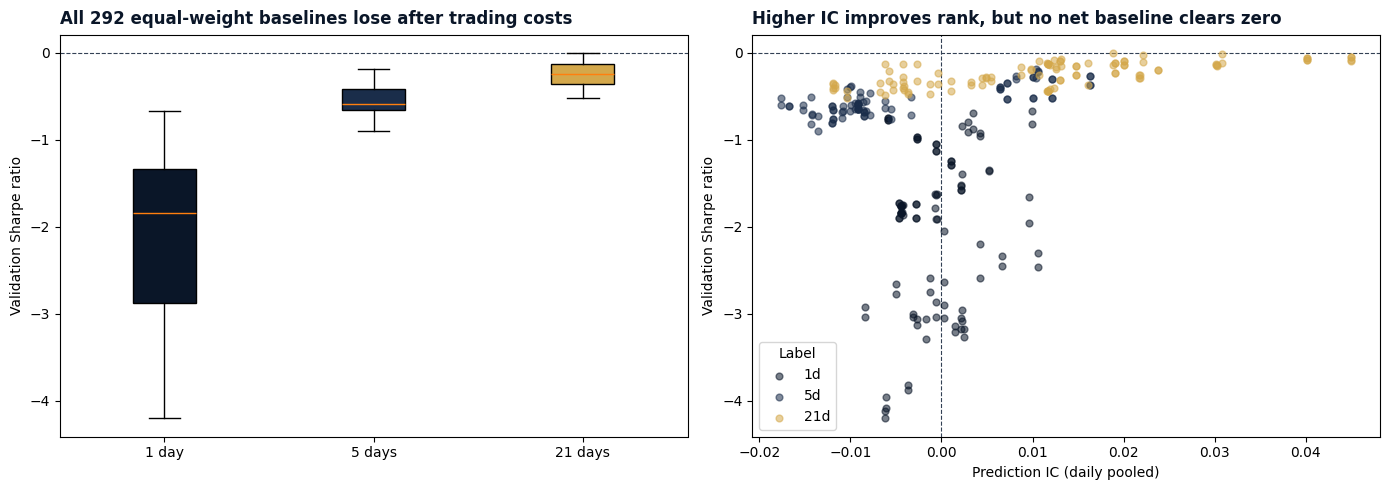

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_colors = [
    utils.style.COLORS["blue"],
    utils.style.COLORS["slate"],
    utils.style.COLORS["amber"],
]
sharpe_by_label = [
    baseline_runs.filter(pl.col("label") == label)["sharpe"].to_numpy() for label in label_order
]
boxes = axes[0].boxplot(
    sharpe_by_label, patch_artist=True, tick_labels=["1 day", "5 days", "21 days"]
)
for patch, color in zip(boxes["boxes"], label_colors, strict=True):
    patch.set_facecolor(color)
utils.style.zero_line(axes[0], at=0.0, axis="y")
axes[0].set_ylabel("Validation Sharpe ratio")
utils.style.add_message_title(axes[0], "All 292 equal-weight baselines lose after trading costs")
for label, color in zip(label_order, label_colors, strict=True):
    frame = baseline_runs.filter(pl.col("label") == label).drop_nulls(["ic_mean", "sharpe"])
    axes[1].scatter(
        frame["ic_mean"].to_numpy(),
        frame["sharpe"].to_numpy(),
        alpha=0.55,
        s=24,
        color=color,
        label=label.replace("fwd_ret_", ""),
    )
utils.style.zero_line(axes[1], at=0.0, axis="x")
utils.style.zero_line(axes[1], at=0.0, axis="y")
axes[1].set_xlabel("Prediction IC (daily pooled)")
axes[1].set_ylabel("Validation Sharpe ratio")
utils.style.add_message_title(axes[1], "Higher IC improves rank, but no net baseline clears zero")
axes[1].legend(title="Label")
fig.tight_layout()
fig.show()

### Selection adjustment uses the 292 semantic variants

The stored cohort table counts all 508 physical rows and overstates the number of trials. The
calculation below reads each semantic leader's daily returns and fold Sharpes, then recomputes
effective-rank DSR and PBO in memory. It uses the declared 252 periods per year and does not
mutate the registry. PBO measures rank instability, not profitability: a low PBO cannot rescue
a leader whose Sharpe is negative.

In [20]:
def _load_fold_sharpes(hashes: list[str]) -> dict[str, np.ndarray]:
    placeholders = ",".join("?" for _ in hashes)
    connection = sqlite3.connect(f"file:{REGISTRY_PATH}?mode=ro", uri=True)
    try:
        rows = connection.execute(
            f"SELECT backtest_hash, fold_id, sharpe FROM backtest_fold_metrics "
            f"WHERE backtest_hash IN ({placeholders}) AND sharpe IS NOT NULL",
            hashes,
        ).fetchall()
    finally:
        connection.close()
    by_hash: dict[str, dict[int, float]] = defaultdict(dict)
    for backtest_hash, fold_id, sharpe in rows:
        by_hash[backtest_hash][int(fold_id)] = float(sharpe)
    fold_ids = sorted({fold_id for values in by_hash.values() for fold_id in values})
    return {
        backtest_hash: np.array([values.get(fold_id, np.nan) for fold_id in fold_ids])
        for backtest_hash, values in by_hash.items()
    }

In [21]:
periods_per_year = periods_per_year_from_setup(CASE_STUDY_ID)
selection_rows = []
for label in label_order:
    hashes = baseline_runs.filter(pl.col("label") == label)["backtest_hash"].to_list()
    returns_by_hash = {
        backtest_hash: load_daily_returns_with_timestamp(CASE_STUDY_ID, backtest_hash)
        for backtest_hash in hashes
    }
    returns_by_hash = {key: value for key, value in returns_by_hash.items() if value is not None}
    metrics = compute_cohort_metrics(
        returns_by_hash,
        periods_per_year=periods_per_year,
        fold_returns_by_hash=_load_fold_sharpes(list(returns_by_hash)),
    )
    selection_rows.append(
        {
            "label": label,
            "variants": metrics["k_variants"],
            "effective_trials": metrics["n_trials_effective_er"],
            "leader_sharpe_252": metrics["leader_sharpe"],
            "dsr_er": metrics["dsr_er"],
            "dsr_pvalue": metrics["dsr_er_pvalue"],
            "pbo": metrics["pbo"],
        }
    )

In [22]:
selection_adjustment = pl.DataFrame(selection_rows)
print(selection_adjustment)

shape: (3, 7)
┌─────────────┬──────────┬──────────────────┬──────────────────┬───────────┬────────────┬──────────┐
│ label       ┆ variants ┆ effective_trials ┆ leader_sharpe_25 ┆ dsr_er    ┆ dsr_pvalue ┆ pbo      │
│ ---         ┆ ---      ┆ ---              ┆ 2                ┆ ---       ┆ ---        ┆ ---      │
│ str         ┆ i64      ┆ f64              ┆ ---              ┆ f64       ┆ f64        ┆ f64      │
│             ┆          ┆                  ┆ f64              ┆           ┆            ┆          │
╞═════════════╪══════════╪══════════════════╪══════════════════╪═══════════╪════════════╪══════════╡
│ fwd_ret_1d  ┆ 100      ┆ 7.873806         ┆ -0.655907        ┆ -0.123363 ┆ 1.0        ┆ 0.014286 │
│ fwd_ret_5d  ┆ 86       ┆ 4.4817           ┆ -0.176168        ┆ -0.022507 ┆ 0.940833   ┆ 0.6      │
│ fwd_ret_21d ┆ 106      ┆ 4.045934         ┆ -0.004236        ┆ -0.009177 ┆ 0.726537   ┆ 0.828571 │
└─────────────┴──────────┴──────────────────┴──────────────────┴───────────┴─

## Key takeaways

1. **The engine plumbing passes.** The zero-cost random-signal Sharpe is about -0.92. Production
   costs are excluded because they turn random daily turnover into a predictable loss.
2. **The frozen baseline has 292 strategies, not 508 trials.** The extra 216 rows belong to 206
   duplicate semantic groups. Every duplicate has identical metrics and daily returns.
3. **No equal-weight baseline earns a positive net Sharpe.** The best result is the 21-day Ridge
   top-5 variant at -0.0043. Its near-zero Sharpe does not establish a tradeable edge.
4. **Selection adjustment reinforces the negative result.** Effective-rank DSR stays below zero
   for every label. The 21-day cohort has DSR about -0.009 with p about 0.73 and PBO about 0.83.
5. **Chapter 17 inherits candidates, not validated alpha.** Allocation can change risk and cost
   exposure, but it must not be described as creating predictive evidence absent here.

**Next:** Test allocation methods on the fixed candidate set without revisiting model selection.